<a href="https://colab.research.google.com/github/nurulfdlharba-dotcom/randomforest/blob/hasil1/hasil%201%20lengkap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import library

In [14]:
# Mengolah dan membaca dataset
import pandas as pd

# Operasi matematika dan numerik
import numpy as np

# Membuat model Random Forest untuk klasifikasi
from sklearn.ensemble import RandomForestClassifier

# Membagi dataset menjadi data training dan testing
from sklearn.model_selection import train_test_split

# Library untuk mengevaluasi performa model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load dataset

In [15]:
# Membaca dataset CSV
df = pd.read_csv('/content/soil_measurements_rows.csv')

# Menampilkan 5 data pertama
print(df.head())

# Menampilkan jumlah baris dan kolom
print("Ukuran dataset:", df.shape)

# Menampilkan nama-nama kolom
print("Nama kolom:", df.columns.tolist())

   id                   timestamp   Hum  Temp   N    P    K   pH   EC  \
0   1  2026-09-01 19:34:25.516134   1.0   1.0   1    1    1  1.0    1   
1   6  2026-05-13 12:26:16.378126  96.7  32.6  40  138  131  5.4  376   
2   7  2026-05-13 12:27:18.586023  97.2  32.5  39  137  130  5.5  374   
3   8  2026-05-13 12:28:20.652853  96.7  32.5  39  137  130  5.6  374   
4   9  2026-05-13 12:29:22.916488  96.7  32.5  39  136  129  5.6  372   

  ai_label recommendation  
0        1              1  
1      NaN            NaN  
2      NaN            NaN  
3      NaN            NaN  
4      NaN            NaN  
Ukuran dataset: (3798, 11)
Nama kolom: ['id', 'timestamp', 'Hum', 'Temp', 'N', 'P', 'K', 'pH', 'EC', 'ai_label', 'recommendation']


# 3. Cleaning dataset

In [16]:
# SEBELUM CLEANING

print("SEBELUM CLEANING")
print("Jumlah baris dan kolom:", df.shape)
print("\nJumlah data kosong:")
print(df[['N', 'P', 'K', 'pH', 'EC']].isnull().sum())

SEBELUM CLEANING
Jumlah baris dan kolom: (3798, 11)

Jumlah data kosong:
N     0
P     0
K     0
pH    0
EC    0
dtype: int64


In [17]:
# PROSES CLEANING

# Membuat salinan dataset
df_clean = df.copy()

# Membersihkan spasi pada nama kolom
df_clean.columns = df_clean.columns.str.strip()

# Memastikan fitur utama berupa angka
features = ['N', 'P', 'K', 'pH', 'EC']
df_clean[features] = df_clean[features].apply(
    pd.to_numeric, errors='coerce'
)

# Menghapus baris yang memiliki nilai kosong pada fitur utama
df_clean = df_clean.dropna(subset=features)

# Menghapus data duplikat
df_clean = df_clean.drop_duplicates()

In [18]:
# SESUDAH CLEANING

print("\n=== SESUDAH CLEANING ===")
print("Jumlah baris dan kolom:", df_clean.shape)
print("\nJumlah data kosong:")
print(df_clean[features].isnull().sum())


=== SESUDAH CLEANING ===
Jumlah baris dan kolom: (3798, 11)

Jumlah data kosong:
N     0
P     0
K     0
pH    0
EC    0
dtype: int64


# 4. EDA (Exploratory Data Analysis)

In [19]:
# =========================
# 1. STATISTIK DESKRIPTIF
# =========================

# Menampilkan statistik dasar setiap fitur
print("=== STATISTIK DESKRIPTIF ===")
print(df_clean[features].describe())

=== STATISTIK DESKRIPTIF ===
                 N            P            K           pH           EC
count  3798.000000  3798.000000  3798.000000  3798.000000  3798.000000
mean     69.149289   199.783570   194.012902     6.681569   500.537388
std      98.568458   232.143641   233.536121     1.048265   485.798985
min       0.000000     0.000000     0.000000     1.000000     0.000000
25%       3.000000    53.000000    45.000000     6.200000   199.000000
50%      18.000000    88.000000    81.000000     6.700000   272.000000
75%      91.750000   255.500000   253.250000     7.200000   626.750000
max     578.000000  1382.000000  1385.000000     9.000000  2956.000000


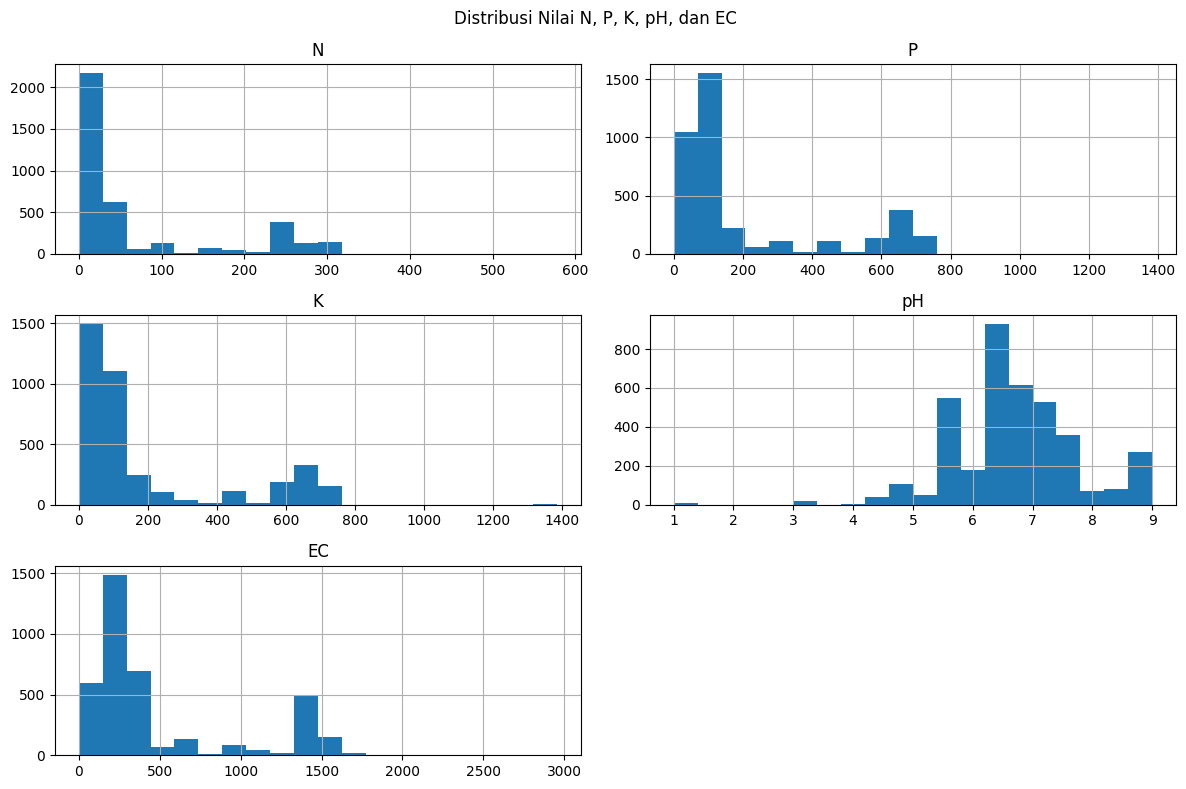

In [20]:
# =========================
# 2. DISTRIBUSI FITUR
# =========================

import matplotlib.pyplot as plt

# Membuat histogram untuk setiap fitur
df_clean[features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribusi Nilai N, P, K, pH, dan EC")
plt.tight_layout()
plt.show()

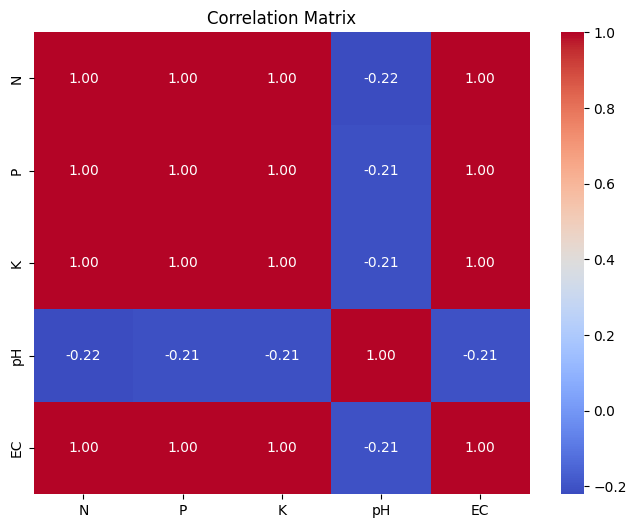

In [21]:
# =========================
# 3. CORRELATION MATRIX
# =========================

import seaborn as sns

# Menghitung korelasi antar fitur
correlation = df_clean[features].corr()

# Menampilkan correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

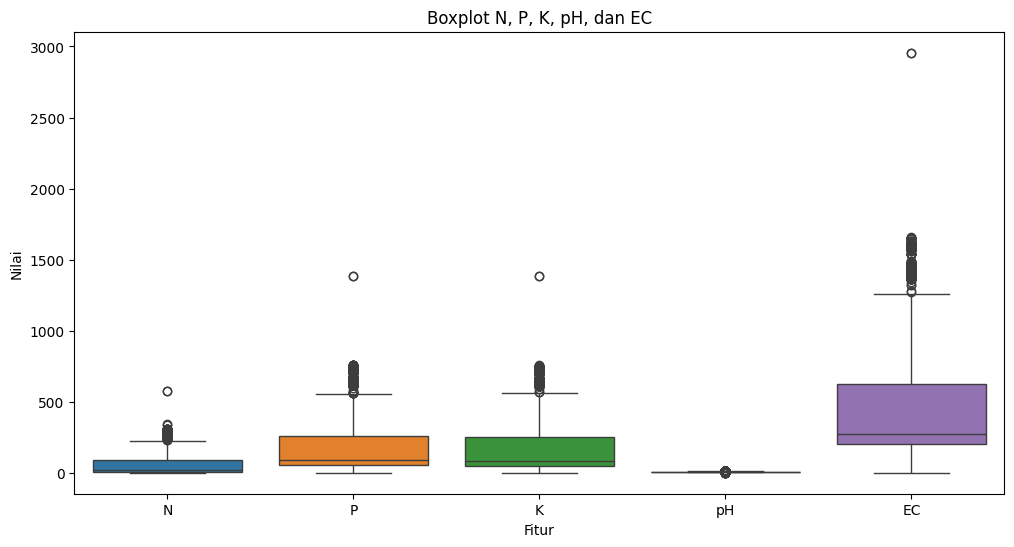

In [22]:
# =========================
# 4. ANALISIS OUTLIER
# =========================

plt.figure(figsize=(12, 6))

# Membuat boxplot untuk melihat nilai yang ekstrem
sns.boxplot(data=df_clean[features])

plt.title("Boxplot N, P, K, pH, dan EC")
plt.xlabel("Fitur")
plt.ylabel("Nilai")

plt.show()

# 5. Menentukan label dan fitur

In [23]:
# =========================
# 1. MELIHAT SELURUH LABEL
# =========================

print("=== LABEL YANG TERSEDIA ===")
print(df_clean['ai_label'].unique())

# Melihat jumlah masing-masing label
print("\n=== JUMLAH SETIAP LABEL ===")
print(df_clean['ai_label'].value_counts(dropna=False))

=== LABEL YANG TERSEDIA ===
['1' nan 'Kurang Subur' 'Sangat Subur' 'Subur' 'Sedang' 'Rendah'
 'Sangat Tinggi' 'Sangat Rendah' 'Tinggi' 'Petak 3' 'Petak 5']

=== JUMLAH SETIAP LABEL ===
ai_label
Kurang Subur     1668
Sangat Rendah     662
Sangat Subur      602
Sedang            517
Rendah            183
NaN                77
Sangat Tinggi      68
Subur              10
1                   6
Tinggi              3
Petak 3             1
Petak 5             1
Name: count, dtype: int64


In [26]:
# =========================
# 2. MENENTUKAN LABEL YANG DIGUNAKAN
# =========================

# Lima kelas yang akan digunakan dalam klasifikasi
selected_labels = [
    'Sangat Rendah',
    'Rendah',
    'Sedang',
    'Tinggi',
    'Sangat Tinggi'
]

print("=== LABEL YANG DIGUNAKAN ===")
print(selected_labels)

=== LABEL YANG DIGUNAKAN ===
['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']


In [27]:
# =========================
# 3. MENGAMBIL DATA DENGAN 5 LABEL
# =========================

# Mengambil hanya data yang memiliki salah satu dari 5 label
df_model = df_clean[
    df_clean['ai_label'].isin(selected_labels)
].copy()

print("\n=== JUMLAH DATA SETELAH FILTER ===")
print("Jumlah data:", len(df_model))


=== JUMLAH DATA SETELAH FILTER ===
Jumlah data: 1433


In [28]:
# =========================
# 4. MENGECEK DISTRIBUSI LABEL
# =========================

print("\n=== DISTRIBUSI 5 LABEL ===")
print(df_model['ai_label'].value_counts())


=== DISTRIBUSI 5 LABEL ===
ai_label
Sangat Rendah    662
Sedang           517
Rendah           183
Sangat Tinggi     68
Tinggi             3
Name: count, dtype: int64


In [29]:
# =========================
# 5. ANALISIS KETIDAKSEIMBANGAN LABEL
# =========================

# Menghitung jumlah setiap kelas
label_counts = df_model['ai_label'].value_counts()

# Menghitung persentase setiap kelas
label_percentage = df_model['ai_label'].value_counts(normalize=True) * 100

print("=== DISTRIBUSI LABEL ===")
for label in label_counts.index:
    print(f"{label}: {label_counts[label]} data ({label_percentage[label]:.2f}%)")

=== DISTRIBUSI LABEL ===
Sangat Rendah: 662 data (46.20%)
Sedang: 517 data (36.08%)
Rendah: 183 data (12.77%)
Sangat Tinggi: 68 data (4.75%)
Tinggi: 3 data (0.21%)


In [30]:
# =========================
# 6. MENENTUKAN FITUR (X)
# =========================

# Fitur yang digunakan untuk memprediksi tingkat kesuburan
features = ['N', 'P', 'K', 'pH', 'EC']

X = df_model[features]

print("=== FITUR YANG DIGUNAKAN ===")
print(features)
print("Jumlah fitur:", X.shape[1])

=== FITUR YANG DIGUNAKAN ===
['N', 'P', 'K', 'pH', 'EC']
Jumlah fitur: 5


In [31]:
# =========================
# 7. MENENTUKAN TARGET (Y)
# =========================

# ai_label menjadi target yang akan diprediksi
y = df_model['ai_label']

print("=== TARGET Y ===")
print(y.head())
print("Jumlah data target:", len(y))

=== TARGET Y ===
2357    Sedang
2358    Rendah
2359    Rendah
2360    Sedang
2361    Rendah
Name: ai_label, dtype: object
Jumlah data target: 1433


In [32]:
# =========================
# 8. CEK X DAN Y
# =========================

print("=== BENTUK DATA ===")
print("X:", X.shape)
print("y:", y.shape)

print("\nJumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])

=== BENTUK DATA ===
X: (1433, 5)
y: (1433,)

Jumlah fitur: 5
Jumlah data: 1433


# 6. Preprocessing data

In [33]:
# =========================
# 1. CEK MISSING VALUE
# =========================

print("=== MISSING VALUE ===")
print(X.isnull().sum())

=== MISSING VALUE ===
N     0
P     0
K     0
pH    0
EC    0
dtype: int64


In [34]:
# =========================
# 2. CEK TIPE DATA
# =========================

print("\n=== TIPE DATA ===")
print(X.dtypes)


=== TIPE DATA ===
N       int64
P       int64
K       int64
pH    float64
EC      int64
dtype: object


In [35]:
# =========================
# 3. CEK DATA DUPLIKAT
# =========================

print("\n=== DATA DUPLIKAT ===")
print("Jumlah duplikat:", X.duplicated().sum())


=== DATA DUPLIKAT ===
Jumlah duplikat: 1077


In [36]:
# Mengecek duplikat berdasarkan fitur dan label
duplicate_check = df_model.duplicated(
    subset=['N', 'P', 'K', 'pH', 'EC', 'ai_label']
)

print("Jumlah duplikat X + y:", duplicate_check.sum())

Jumlah duplikat X + y: 1076


In [37]:
# =========================
# 4. CEK NILAI TIDAK VALID
# =========================

print("=== NILAI MINIMUM ===")
print(X.min())

print("\n=== NILAI MAKSIMUM ===")
print(X.max())

=== NILAI MINIMUM ===
N     0.0
P     0.0
K     0.0
pH    4.5
EC    0.0
dtype: float64

=== NILAI MAKSIMUM ===
N      343.0
P      735.0
K      733.0
pH       9.0
EC    1613.0
dtype: float64


In [38]:
# =========================
# 5. CEK NILAI 0
# =========================

# Menghitung jumlah nilai 0 pada setiap fitur
zero_values = (X == 0).sum()

print("=== JUMLAH NILAI 0 ===")
print(zero_values)

=== JUMLAH NILAI 0 ===
N     646
P     162
K     182
pH      0
EC      1
dtype: int64


In [39]:
# =========================
# 6. MELIHAT DATA DENGAN N = 0
# =========================

# Menampilkan beberapa data dengan nilai N = 0
print(df_model[df_model['N'] == 0][
    ['N', 'P', 'K', 'pH', 'EC', 'ai_label']
].head(20))

      N   P   K   pH   EC       ai_label
2357  0   0   0  5.6    0         Sedang
2364  0   0   0  8.1   62         Rendah
2434  0  27  19  7.0  146  Sangat Rendah
2435  0  27  19  7.0  146  Sangat Rendah
2436  0  27  19  7.0  146  Sangat Rendah
2437  0  27  19  7.1  146         Rendah
2438  0  27  19  7.1  146         Rendah
2439  0  27  19  7.1  146         Rendah
2440  0  27  19  7.1  145         Rendah
2441  0  27  19  7.1  145         Rendah
2442  0  27  19  7.2  145         Rendah
2443  0  27  19  7.2  145         Rendah
2444  0  27  19  7.2  145         Rendah
2445  0  27  19  7.2  145         Rendah
2446  0  26  18  7.2  144         Rendah
2447  0  26  18  7.3  144         Rendah
2448  0  26  18  7.3  144         Rendah
2449  0  26  18  7.3  144         Rendah
2450  0  26  18  7.3  144         Rendah
2451  0  26  18  7.3  144         Rendah


In [40]:
# =========================
# 7. ENCODING LABEL
# =========================

# Mengubah label teks menjadi angka
label_mapping = {
    'Sangat Rendah': 0,
    'Rendah': 1,
    'Sedang': 2,
    'Tinggi': 3,
    'Sangat Tinggi': 4
}

y_encoded = y.map(label_mapping)

# Menampilkan hasil encoding
print("=== HASIL ENCODING LABEL ===")
print(y_encoded.head())

# Mengecek jumlah setiap label setelah encoding
print("\n=== DISTRIBUSI LABEL ===")
print(y_encoded.value_counts().sort_index())

=== HASIL ENCODING LABEL ===
2357    2
2358    1
2359    1
2360    2
2361    1
Name: ai_label, dtype: int64

=== DISTRIBUSI LABEL ===
ai_label
0    662
1    183
2    517
3      3
4     68
Name: count, dtype: int64


In [42]:
# =========================
# 8. CEK HASIL AKHIR PREPROCESSING
# =========================

print("=== CEK HASIL AKHIR PREPROCESSING ===")

# Mengecek ukuran X dan y
print("Ukuran X:", X.shape)
print("Ukuran y:", y_encoded.shape)

# Mengecek tipe data X
print("\n=== TIPE DATA X ===")
print(X.dtypes)

# Mengecek missing value pada X
print("\n=== MISSING VALUE X ===")
print(X.isnull().sum())

# Mengecek missing value pada y
print("\n=== MISSING VALUE Y ===")
print(y_encoded.isnull().sum())

# Mengecek jumlah fitur
print("\nJumlah fitur:", X.shape[1])

# Mengecek apakah jumlah data X dan y sama
print("\nJumlah data X:", len(X))
print("Jumlah data y:", len(y_encoded))

=== CEK HASIL AKHIR PREPROCESSING ===
Ukuran X: (1433, 5)
Ukuran y: (1433,)

=== TIPE DATA X ===
N       int64
P       int64
K       int64
pH    float64
EC      int64
dtype: object

=== MISSING VALUE X ===
N     0
P     0
K     0
pH    0
EC    0
dtype: int64

=== MISSING VALUE Y ===
0

Jumlah fitur: 5

Jumlah data X: 1433
Jumlah data y: 1433


# 7. Train-Test split

In [43]:
# Membagi data menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Menampilkan ukuran masing-masing data
print("=== HASIL TRAIN-TEST SPLIT ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

=== HASIL TRAIN-TEST SPLIT ===
X_train: (1146, 5)
X_test : (287, 5)
y_train: (1146,)
y_test : (287,)


In [44]:
# =========================
# DISTRIBUSI LABEL TRAINING
# =========================

print("\n=== DISTRIBUSI LABEL DATA TRAINING ===")
print(y_train.value_counts().sort_index())


=== DISTRIBUSI LABEL DATA TRAINING ===
ai_label
0    530
1    146
2    414
3      2
4     54
Name: count, dtype: int64


In [45]:
# =========================
# DISTRIBUSI LABEL TESTING
# =========================

print("\n=== DISTRIBUSI LABEL DATA TESTING ===")
print(y_test.value_counts().sort_index())


=== DISTRIBUSI LABEL DATA TESTING ===
ai_label
0    132
1     37
2    103
3      1
4     14
Name: count, dtype: int64


# 8. Menangani class imbalance

In [46]:
# =========================
# 1. CEK DISTRIBUSI DATA TRAINING
# =========================

print("=== DISTRIBUSI LABEL DATA TRAINING ===")

print(y_train.value_counts().sort_index())

=== DISTRIBUSI LABEL DATA TRAINING ===
ai_label
0    530
1    146
2    414
3      2
4     54
Name: count, dtype: int64


In [49]:
# =========================
# 2. MENGGUNAKAN class_weight='balanced'
# =========================

RandomForestClassifier(
    class_weight='balanced'
)

RandomForestClassifier(class_weight='balanced')

In [48]:
# =========================
# 3. PERSENTASE DATA TRAINING
# =========================

label_percentage_train = (
    y_train.value_counts(normalize=True)
    .sort_index() * 100
)

print("=== PERSENTASE LABEL DATA TRAINING ===")

for label, percentage in label_percentage_train.items():
    print(f"Kelas {label}: {percentage:.2f}%")

=== PERSENTASE LABEL DATA TRAINING ===
Kelas 0: 46.25%
Kelas 1: 12.74%
Kelas 2: 36.13%
Kelas 3: 0.17%
Kelas 4: 4.71%


# 9. Membuat dan melatih random forest

In [50]:
# =========================
# 1. MEMBUAT MODEL RANDOM FOREST
# =========================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

print("Model Random Forest berhasil dibuat.")

Model Random Forest berhasil dibuat.


In [51]:
# =========================
# 2. MELATIH RANDOM FOREST
# =========================

rf_model.fit(X_train, y_train)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


# 10. Melihat prediksi

In [52]:
# =========================
# TAHAP 10
# PREDIKSI DATA TESTING
# =========================

y_pred = rf_model.predict(X_test)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred))

Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 287


# 11. Evaluasi model

In [53]:
# =========================
# 1. EVALUASI MODEL
# =========================

# Menghitung accuracy
accuracy = accuracy_score(y_test, y_pred)

print("=== HASIL EVALUASI RANDOM FOREST ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Accuracy : {accuracy * 100:.2f}%")

# Classification report
print("\n=== CLASSIFICATION REPORT ===")

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        'Sangat Rendah',
        'Rendah',
        'Sedang',
        'Tinggi',
        'Sangat Tinggi'
    ],
    zero_division=0
))

=== HASIL EVALUASI RANDOM FOREST ===
Accuracy : 0.9895
Accuracy : 98.95%

=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Sangat Rendah       0.99      0.99      0.99       132
       Rendah       0.97      0.97      0.97        37
       Sedang       1.00      1.00      1.00       103
       Tinggi       0.50      1.00      0.67         1
Sangat Tinggi       1.00      0.93      0.96        14

     accuracy                           0.99       287
    macro avg       0.89      0.98      0.92       287
 weighted avg       0.99      0.99      0.99       287



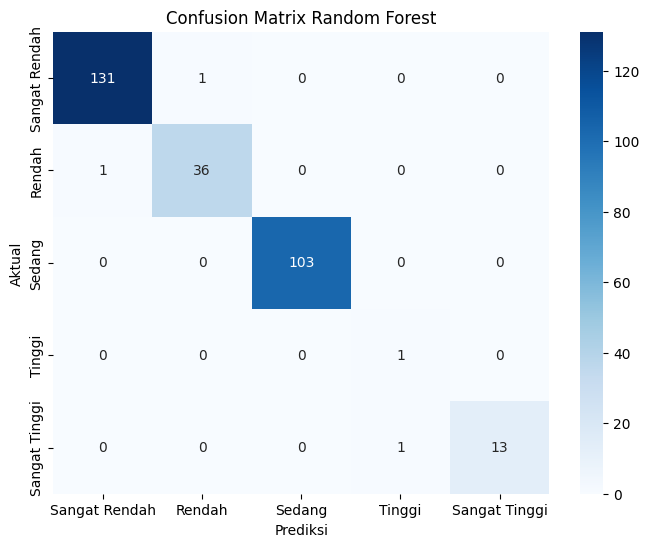

In [54]:
# =========================
# 2. CONFUSION MATRIX
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Sangat Rendah',
        'Rendah',
        'Sedang',
        'Tinggi',
        'Sangat Tinggi'
    ],
    yticklabels=[
        'Sangat Rendah',
        'Rendah',
        'Sedang',
        'Tinggi',
        'Sangat Tinggi'
    ]
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Random Forest')
plt.show()

# 12. Cross-Validation

In [55]:
# =========================
# 1. STRATIFIED 3-FOLD CROSS-VALIDATION
# =========================

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Membuat Stratified 3-Fold
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Stratified 3-Fold Cross-Validation berhasil dibuat.")

Stratified 3-Fold Cross-Validation berhasil dibuat.


In [56]:
# =========================
# 2. MENJALANKAN CROSS-VALIDATION
# =========================

cv_scores = cross_val_score(
    rf_model,
    X,
    y_encoded,
    cv=skf,
    scoring='accuracy'
)

print("=== HASIL CROSS-VALIDATION ===")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nRata-rata Accuracy: {cv_scores.mean():.4f}")
print(f"Rata-rata Accuracy: {cv_scores.mean() * 100:.2f}%")

=== HASIL CROSS-VALIDATION ===
Fold 1: 0.9937
Fold 2: 0.9749
Fold 3: 0.9769

Rata-rata Accuracy: 0.9819
Rata-rata Accuracy: 98.19%


# 13. Feature Importance

In [57]:
# =========================
# 1. FEATURE IMPORTANCE
# =========================

# Mengambil nilai importance dari setiap fitur
feature_importance = rf_model.feature_importances_

# Membuat tabel feature importance
importance_df = pd.DataFrame({
    'Fitur': features,
    'Importance': feature_importance
})

# Mengurutkan dari yang terbesar
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("=== FEATURE IMPORTANCE ===")
print(importance_df)

=== FEATURE IMPORTANCE ===
  Fitur  Importance
4    EC    0.271184
1     P    0.249208
2     K    0.235924
3    pH    0.144728
0     N    0.098956


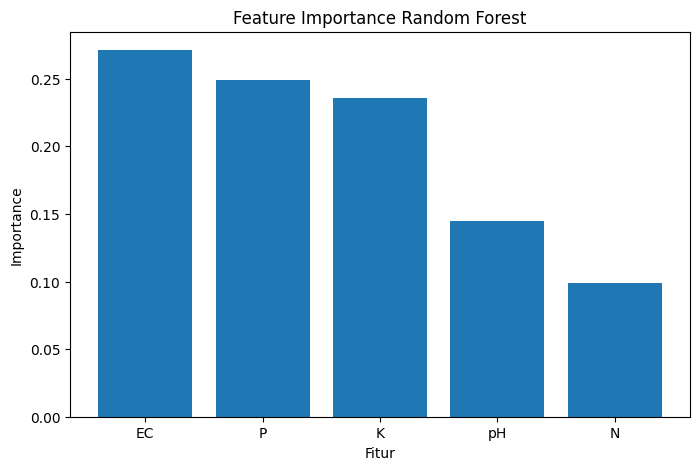

In [58]:
# =========================
# 2. VISUALISASI FEATURE IMPORTANCE
# =========================

plt.figure(figsize=(8, 5))

plt.bar(
    importance_df['Fitur'],
    importance_df['Importance']
)

plt.xlabel('Fitur')
plt.ylabel('Importance')
plt.title('Feature Importance Random Forest')

plt.show()